In [1]:
import json
import sys
sys.path.insert(0, "..")

import pandas as pd
import config
from src.db_io import leer_tabla_sqlite

df = leer_tabla_sqlite(config.ORO_DB, "cliente_features")
resumen = {
    "n_filas": len(df),
    "n_columnas": df.shape[1],
    "nulos_por_columna": df.isnull().sum().to_dict(),
}
(config.OUTPUTS_DIR / "eda").mkdir(parents=True, exist_ok=True)
with open(config.OUTPUTS_DIR / "eda" / "resumen_shape.json", "w") as f:
    json.dump({k: v for k, v in resumen.items() if k != "nulos_por_columna"} |
              {"nulos_por_columna": {k: int(v) for k, v in resumen["nulos_por_columna"].items()}}, f, indent=2)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
numero_id,860223.0,NaN,NaN,NaN,11296873133658780.0,5324473300252032000.0,-9223363218022227968.0,-4595761860927589376.0,19608476502043612.0,4615083692997420032.0,9223362823850479616.0
grupo_edad,860223,5,36-49,236761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_genero,860130,4,femenino,472622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_segmento,860223,3,personal,645970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_tipo_de_vivienda,268532,4,FAMILIAR,129359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
saldo_invertido_no_etiqueta,860223.0,NaN,NaN,NaN,3107743.833571,26471122.358044,0.0,0.0,0.0,0.0,4064556340.99
n_productos_inversion_no_etiqueta,860223.0,NaN,NaN,NaN,0.240435,0.440352,0.0,0.0,0.0,0.0,2.0
tiene_historial_producto,860223.0,NaN,NaN,NaN,0.615503,0.486476,0.0,0.0,1.0,1.0,1.0
sin_ninguna_senal,860223.0,NaN,NaN,NaN,0.000081,0.00902,0.0,0.0,0.0,0.0,1.0


,variable,categoria,tasa_adopcion,n_clientes
0,grupo_edad,18-25,0.032772,110400
1,grupo_edad,26-35,0.076347,212490
2,grupo_edad,36-49,0.095155,236761
3,grupo_edad,50-65,0.079983,163234
4,grupo_edad,65+,0.045217,137338
5,desc_genero,femenino,0.083407,472622
6,desc_genero,masculino,0.057337,387430
7,desc_genero,no binario,0.044444,45
8,desc_genero,trans,0.000000,33
9,desc_genero,NaN,0.000000,93


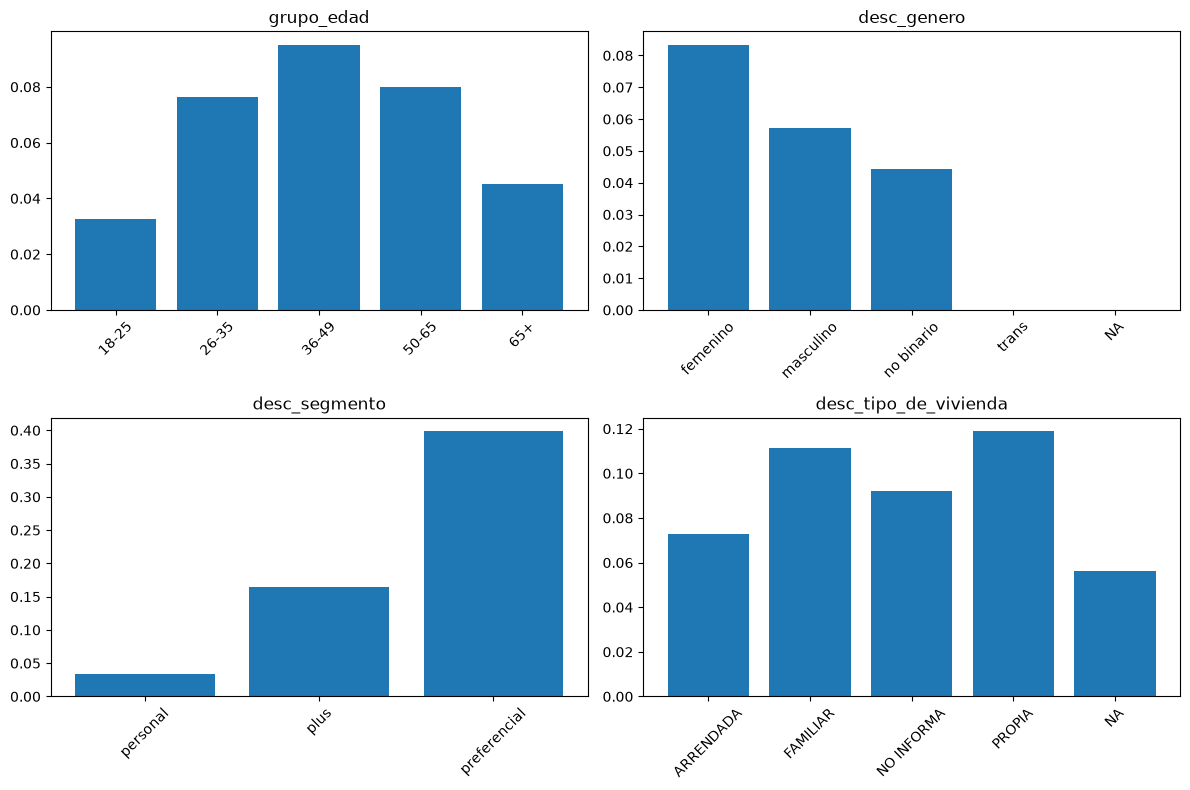

In [2]:
import matplotlib.pyplot as plt

sensibles = ["grupo_edad", "desc_genero", "desc_segmento", "desc_tipo_de_vivienda"]
tablas = []
for col in sensibles:
    t = df.groupby(col, dropna=False)["etiqueta_adopcion"].agg(["mean", "count"]).reset_index()
    t.insert(0, "variable", col)
    t = t.rename(columns={col: "categoria", "mean": "tasa_adopcion", "count": "n_clientes"})
    tablas.append(t)

resumen_sensibles = pd.concat(tablas, ignore_index=True)
resumen_sensibles.to_csv(config.OUTPUTS_DIR / "eda" / "tasas_adopcion_por_segmento.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, sensibles):
    subset = resumen_sensibles[resumen_sensibles["variable"] == col]
    ax.bar(subset["categoria"].fillna("NA").astype(str), subset["tasa_adopcion"])
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda" / "tasas_adopcion_por_segmento.png")

resumen_sensibles

In [3]:
saldo_cols = [c for c in df.columns if c.endswith("_saldo_snapshot")]
resumen_saldos = df.groupby("etiqueta_adopcion")[saldo_cols + ["capacidad_ahorro"]].mean()
print(resumen_saldos)

# SPEC_V2 §2: la población de entrenamiento es toda la base apta (única exclusión:
# clientes sin ninguna señal en ninguna fuente). La de scoring es TODA la base.
poblacion_entrenamiento = df.loc[df["apto_entrenamiento"] == 1, ["numero_id"]]
poblacion_entrenamiento.to_csv(config.OUTPUTS_DIR / "eda" / "poblacion_entrenamiento.csv", index=False)

print(f"población de entrenamiento: {len(poblacion_entrenamiento)} de {len(df)} clientes")
print(f"excluidos (sin ninguna señal): {int(df['sin_ninguna_senal'].sum())}")
print(f"sin historial de producto (negativos legítimos, SÍ entrenan): "
      f"{int(((df['tiene_historial_producto'] == 0) & (df['apto_entrenamiento'] == 1)).sum())}")


                   cuenta_ahorro_saldo_snapshot  \
etiqueta_adopcion                                 
0                                  2.105510e+06   
1                                  1.201707e+07   

                   cuenta_corriente_saldo_snapshot  bolsillos_saldo_snapshot  \
etiqueta_adopcion                                                              
0                                     30070.404246              2.315580e+05   
1                                    205755.994290              1.743983e+06   

                   fiducuenta_saldo_snapshot  cdt_saldo_snapshot  \
etiqueta_adopcion                                                  
0                               1.192572e+06        1.111571e+06   
1                               8.635519e+06        4.884079e+06   

                   inversion_virtual_saldo_snapshot  invesbot_saldo_snapshot  \
etiqueta_adopcion                                                              
0                                      0.

población de entrenamiento: 860153 de 860223 clientes
excluidos (sin ninguna señal): 70
sin historial de producto (negativos legítimos, SÍ entrenan): 330683
